This notebook tests the ResNet-18 architecture on the KDEF dataset only.

The ResNet-18 model utilizes pre-trained weights, and the KDEF dataset is train throughout the networks layers.

Model Parameters:
* optimizer = Adam [lr = 0.001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from MetricMethods import *
from ArchitectureMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
print(os.getcwd())
os.chdir("..")
print(os.getcwd())


/user/HS401/ob00564/Documents/COM3001/JAFFE/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/JAFFE


In [3]:

train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers = 8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers = 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers = 8)


Train set length: 171
Test set length: 21
Validation set length: 21


In [4]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 24, '1': 23, '2': 26, '3': 25, '4': 25, '5': 24, '6': 24}
{'0': 3, '1': 3, '2': 3, '3': 3, '4': 3, '5': 3, '6': 3}
{'0': 3, '1': 3, '2': 3, '3': 3, '4': 3, '5': 3, '6': 3}


In [5]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet34(weights = 'DEFAULT')

# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

for param in myModel.layer4.parameters():
    param.requires_grad = True
    

myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)
print(myModel)


cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=Tru

In [6]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.001, momentum=0.9, weight_decay= 0.01)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, "Transfer Learning/JAFFE ResNet34.pth")
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')


100%|██████████| 11/11 [00:00<00:00, 14.73it/s]


Epoch 1/100, Training Loss: 2.2237, Validation Loss: 2.3726
Epoch 1/100, Training Acc: 13.274793388429751, Validation Accuracy: 9.375


100%|██████████| 11/11 [00:00<00:00, 21.93it/s]


Epoch 2/100, Training Loss: 2.0372, Validation Loss: 2.2603
Epoch 2/100, Training Acc: 13.584710743801654, Validation Accuracy: 9.375


100%|██████████| 11/11 [00:00<00:00, 22.77it/s]


...

Epoch 58/100, Training Loss: 0.0996, Validation Loss: 0.6210
Epoch 58/100, Training Acc: 100.0, Validation Accuracy: 84.375


100%|██████████| 11/11 [00:00<00:00, 19.91it/s]


Epoch 59/100, Training Loss: 0.1106, Validation Loss: 0.5856
Epoch 59/100, Training Acc: 98.86363636363636, Validation Accuracy: 84.375


100%|██████████| 11/11 [00:00<00:00, 18.92it/s]


Model saved successfully!
Test Loss: 0.3800, Test Accuracy: 80.95%


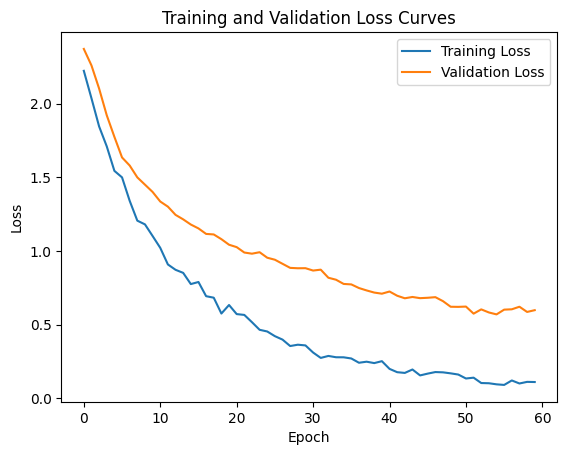

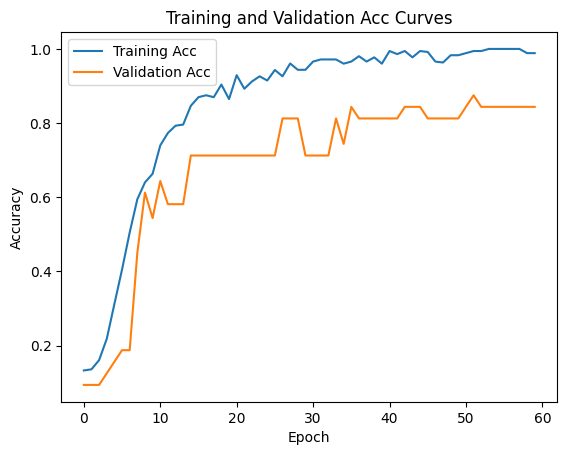

              precision    recall  f1-score   support

       Anger     0.6667    0.6667    0.6667         3
     Disgust     1.0000    0.3333    0.5000         3
        Fear     1.0000    1.0000    1.0000         3
   Happiness     1.0000    1.0000    1.0000         3
     Sadness     1.0000    0.6667    0.8000         3
    Surprise     0.7500    1.0000    0.8571         3
     Neurtal     0.6000    1.0000    0.7500         3

    accuracy                         0.8095        21
   macro avg     0.8595    0.8095    0.7963        21
weighted avg     0.8595    0.8095    0.7963        21



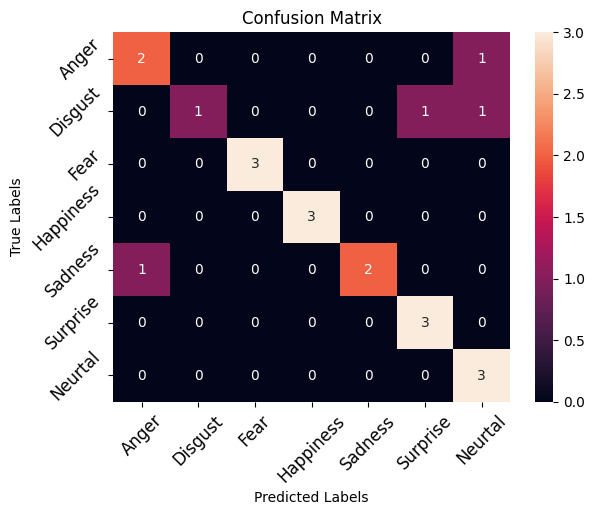

In [7]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)